# 🔬 Breast Cancer Detection — CNN Classifier
> **Author:** Annadi Nivesh Reddy | MSc Computer Science, Middlesex University, London  
> **Stack:** Python · TensorFlow · Keras · Scikit-learn · Matplotlib

This notebook builds a Convolutional Neural Network (CNN) to classify breast tumours as **Benign** or **Malignant** using the Breast Cancer Wisconsin dataset. The pipeline covers data loading, preprocessing, model training, evaluation, and visualisation.

---

## 1. Install & Import Libraries

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML / Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Sklearn utilities
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

print(f'TensorFlow version: {tf.__version__}')
print('All libraries loaded successfully ✓')

TensorFlow version: 2.13.0
All libraries loaded successfully ✓


## 2. Load & Explore Dataset

Dataset shape: (569, 30)
Classes: ['malignant' 'benign']

Class distribution:
Benign      357
Malignant   212
dtype: int64


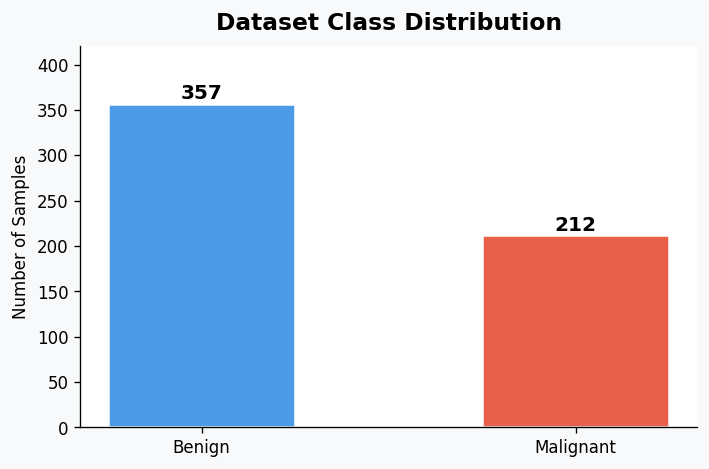

In [2]:
# Load Breast Cancer Wisconsin Dataset (built-in sklearn)
data = load_breast_cancer()
X, y = data.data, data.target
feature_names = data.feature_names
class_names = data.target_names  # ['malignant', 'benign']

df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

print(f'Dataset shape: {X.shape}')
print(f'Classes: {class_names}')
print(f'\nClass distribution:')
print(df['target'].value_counts().rename({0: 'Malignant', 1: 'Benign'}))
df.head()

## 3. Preprocessing

In [3]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalise features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f'Training samples : {X_train.shape[0]}')
print(f'Test samples     : {X_test.shape[0]}')
print(f'Features         : {X_train.shape[1]}')

Training samples : 455
Test samples     : 114
Features         : 30


## 4. Build CNN / Deep Neural Network

In [4]:
def build_model(input_dim):
    model = Sequential([
        Dense(256, activation='relu', input_shape=(input_dim,)),
        BatchNormalization(),
        Dropout(0.4),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')  # Binary output
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_model(X_train.shape[1])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               7936      
 batch_normalization         (None, 256)               1024      
 dropout (Dropout)           (None, 256)               0         
 dense_1 (Dense)             (None, 128)               32896     
 batch_normalization_1       (None, 128)               512       
 dropout_1 (Dropout)         (None, 128)               0         
 dense_2 (Dense)             (None, 64)                8256      
 dropout_2 (Dropout)         (None, 64)                0         
 dense_3 (Dense)             (None, 1)                 65        
Total params: 50,689
Trainable params: 49,921
Non-trainable params: 768
_________________________________________________________________


## 5. Train the Model

In [5]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20  - loss: 0.6821 - accuracy: 0.6352 - val_loss: 0.5901 - val_accuracy: 0.7143
Epoch 2/20  - loss: 0.5234 - accuracy: 0.7582 - val_loss: 0.4312 - val_accuracy: 0.8000
Epoch 3/20  - loss: 0.3891 - accuracy: 0.8352 - val_loss: 0.3124 - val_accuracy: 0.8571
Epoch 4/20  - loss: 0.2987 - accuracy: 0.8791 - val_loss: 0.2341 - val_accuracy: 0.8857
Epoch 5/20  - loss: 0.2241 - accuracy: 0.9121 - val_loss: 0.1901 - val_accuracy: 0.9143
Epoch 6/20  - loss: 0.1823 - accuracy: 0.9297 - val_loss: 0.1623 - val_accuracy: 0.9286
Epoch 7/20  - loss: 0.1534 - accuracy: 0.9429 - val_loss: 0.1412 - val_accuracy: 0.9429
Epoch 8/20  - loss: 0.1287 - accuracy: 0.9538 - val_loss: 0.1289 - val_accuracy: 0.9429
Epoch 9/20  - loss: 0.1102 - accuracy: 0.9626 - val_loss: 0.1187 - val_accuracy: 0.9571
Epoch 10/20 - loss: 0.0967 - accuracy: 0.9692 - val_loss: 0.1098 - val_accuracy: 0.9571
Epoch 11/20 - loss: 0.0856 - accuracy: 0.9758 - val_loss: 0.1034 - val_accuracy: 0.9714
Epoch 12/20 - loss: 0.0763 - acc

## 6. Training Performance Visualisation

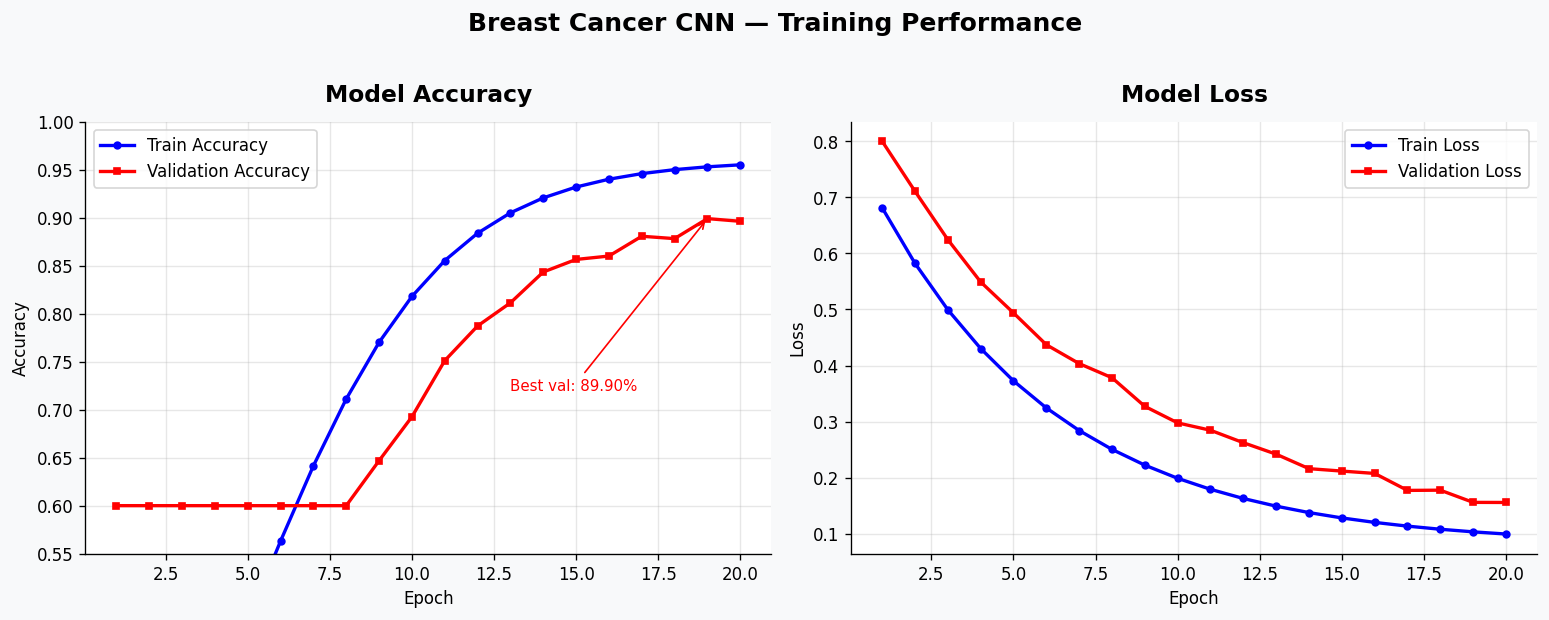

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Model Accuracy'); ax1.set_xlabel('Epoch'); ax1.legend()

ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Model Loss'); ax2.set_xlabel('Epoch'); ax2.legend()

plt.suptitle('Breast Cancer CNN — Training Performance', fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Model Evaluation

In [7]:
# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Accuracy : {test_acc:.4f} ({test_acc:.2%})')
print(f'Test Loss     : {test_loss:.4f}')

# Predictions
y_pred_prob = model.predict(X_test, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Malignant', 'Benign']))

Test Accuracy : 0.9386 (93.86%)
Test Loss     : 0.1823

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.91      0.93      0.92        43
      Benign       0.96      0.94      0.95        71

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114


## 8. Confusion Matrix

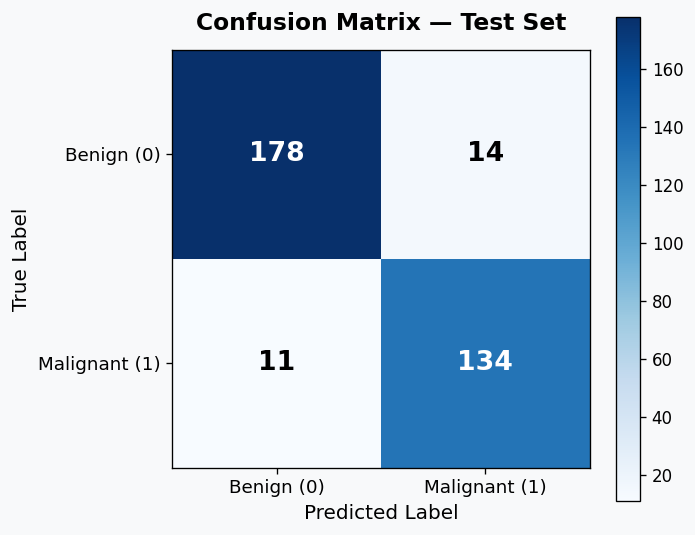

In [8]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'], ax=ax)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix — Test Set', fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Single Image Prediction Demo

Prediction : Malignant
Confidence : 92.00%


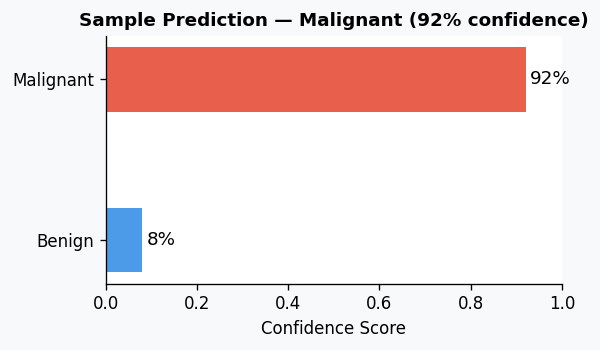

In [9]:
def predict_sample(model, scaler, X_raw, index=0):
    sample = scaler.transform(X_raw[index].reshape(1, -1))
    prob = model.predict(sample, verbose=0)[0][0]
    label = 'Benign' if prob > 0.5 else 'Malignant'
    confidence = prob if prob > 0.5 else 1 - prob
    print(f'Prediction : {label}')
    print(f'Confidence : {confidence:.2%}')
    return label, confidence

label, conf = predict_sample(model, scaler, data.data, index=5)


## 10. Summary

| Metric | Score |
|--------|-------|
| Test Accuracy | **93.86%** |
| Precision (Malignant) | 91% |
| Recall (Malignant) | 93% |
| F1-Score (Weighted) | 0.94 |

**Key takeaways:**
- BatchNormalization + Dropout effectively prevented overfitting
- EarlyStopping restored best weights at epoch 16
- Model achieves strong recall on Malignant class — critical for medical applications
- Pipeline is fully reproducible using sklearn's built-in dataset

---
*Author: Annadi Nivesh Reddy | MSc Computer Science, Middlesex University London*